In [1]:
import pandas as pd
import numpy as np
from joblib import load
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\function_dataset_cleaned.csv')

In [3]:
X = df.drop(columns=['label'])
y = df['label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

## 特徵工程

In [5]:
# 先將原本100個欄位拿去訓練模型
best_model = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v1\best_model.joblib')
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("原始特徵:")
print(f"準確度: {accuracy:.3f}")

原始特徵:
準確度: 0.821


In [7]:
print(f"混淆矩陣:\n{confusion_matrix(y_test, y_pred)}")

混淆矩陣:
[[95  0  0  0  2  2  0  1]
 [ 0 85  0  2  2 10  0  1]
 [ 0  1 87  0  0  2 10  0]
 [ 0  1  9 73  4  0 12  1]
 [ 5  0  8  6 70  2  9  0]
 [ 2  5  2  8  7 73  1  2]
 [ 0  0  6  5  4  2 83  0]
 [ 4  0  1  0  1  1  2 91]]


In [8]:
print(f"分類報告:\n{classification_report(y_test, y_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.90      0.95      0.92       100
       cubic       0.92      0.85      0.89       100
 exponential       0.77      0.87      0.82       100
      linear       0.78      0.73      0.75       100
 logarithmic       0.78      0.70      0.74       100
   quadratic       0.79      0.73      0.76       100
  reciprocal       0.71      0.83      0.76       100
        sine       0.95      0.91      0.93       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



In [9]:
# 將原始資料標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 訓練集

In [10]:
train_first_diff = np.diff(X_train.values, axis=1)          # 一階差分
train_second_diff = np.diff(X_train.values, n=2, axis=1)    # 二階差分
train_amplitude = X_train.max(axis=1) - X_train.min(axis=1) # 變化總幅度

train_x = np.linspace(-2, 2, X_train.shape[1]).reshape(-1, 1)
train_slopes = []                                           # 每一筆函數的整體迴歸斜率
for row in X_train.values:
    train_model = LinearRegression()
    train_model.fit(train_x, row)
    train_slopes.append(train_model.coef_[0])
train_slopes = np.array(train_slopes)

In [11]:
print(f"訓練數據的形狀: {X_train_scaled.shape}")

訓練數據的形狀: (3200, 100)


In [12]:
print(f"原始最大值:\n{X_train.max(axis=0)}\n")              # 最大值
print(f"標準化後的最大值:\n{X_train_scaled.max(axis=0)}\n")

原始最大值:
y_000    19.516391
y_001    17.969906
y_002    17.504949
y_003    16.425775
y_004    15.546557
           ...    
y_095    16.112309
y_096    16.635983
y_097    17.456970
y_098    18.585863
y_099    18.986480
Length: 100, dtype: float64

標準化後的最大值:
[4.62547743 4.42319885 4.4856857  4.36301145 4.2829817  4.30000758
 4.36878522 4.22254207 4.50477391 4.17495722 4.01208525 4.14887202
 4.04419967 4.07575445 3.96392289 3.75466789 3.78087886 3.65481
 3.80613254 3.35027633 3.62466769 3.76431905 3.47591875 3.42039211
 3.16273374 2.97571571 2.83152982 2.99015491 2.77308125 2.7692918
 3.00958413 2.60561532 2.57604612 2.54309203 2.51204422 2.50218557
 2.56765927 2.36985855 2.54439045 2.46677669 2.64660235 2.65017168
 2.59748237 2.55007875 2.52697078 2.67071984 2.67180003 2.80235228
 2.77190999 2.73679135 2.81418965 2.80094018 2.79833972 2.76820471
 2.76254233 2.72836859 2.69743554 2.91993088 2.53097803 2.77164826
 2.69543899 2.56179814 2.55963785 2.59983794 2.63843873 2.7756881
 2.74530895 2

In [13]:
print(f"原始最小值:\n{X_train.min(axis=0)}\n")              # 最小值
print(f"標準化後的最小值:\n{X_train_scaled.min(axis=0)}\n")

原始最小值:
y_000   -18.046258
y_001   -17.189638
y_002   -16.344650
y_003   -15.721408
y_004   -14.734648
           ...    
y_095   -16.800721
y_096   -17.198838
y_097   -18.420420
y_098   -19.196022
y_099   -20.150363
Length: 100, dtype: float64

標準化後的最小值:
[-4.43937482 -4.40093983 -4.36085689 -4.35506082 -4.24069542 -4.24044417
 -4.28832238 -4.12838855 -4.04890487 -4.05010011 -3.97259261 -3.91526167
 -3.98109376 -3.89862646 -3.82142699 -3.74063001 -3.70966883 -3.62955859
 -3.71470463 -3.5135106  -3.63479254 -3.34677477 -3.54652708 -3.17840869
 -3.11260592 -3.12960329 -3.1701063  -3.02304256 -2.84932832 -2.77723764
 -2.86652343 -2.83927402 -2.72156016 -2.74723504 -2.81254618 -2.72281139
 -2.62190353 -2.66870156 -2.67886161 -2.71143062 -2.6577626  -2.75313128
 -2.86080897 -2.96802623 -2.85654132 -2.94015689 -2.89123724 -2.8326969
 -2.60856228 -2.64153089 -2.62494531 -2.6785275  -2.66089764 -2.7075827
 -2.70645877 -2.68903808 -2.68162848 -2.68961849 -2.60870479 -2.97118942
 -2.73792072 -2.8

In [14]:
print(f"原始平均值:\n{X_train.mean(axis=0)}\n")

原始平均值:
y_000    0.349484
y_001    0.345789
y_002    0.341333
y_003    0.337525
y_004    0.330841
           ...   
y_095    0.237021
y_096    0.251712
y_097    0.256921
y_098    0.264700
y_099    0.275633
Length: 100, dtype: float64



In [15]:
print(f"原始標準差:\n{X_train.std(axis=0)}\n")

原始標準差:
y_000    4.144416
y_001    3.985096
y_002    3.826906
y_003    3.687995
y_004    3.553154
           ...   
y_095    3.425225
y_096    3.557164
y_097    3.691980
y_098    3.840059
y_099    3.989270
Length: 100, dtype: float64



In [16]:
print(f"迴歸斜率:(取前5筆資料)\n{train_slopes[:5]}\n")

迴歸斜率:(取前5筆資料)
[ 0.78529431 -0.32550953  0.6782538  -1.53071435  0.42824123]



In [17]:
print("經過一階差分處理後的結果:(取前5筆資料)")
train_first_diff_mean = train_first_diff.mean(axis=1)
train_first_diff_std = train_first_diff.std(axis=1)
print(f"平均值:\n{train_first_diff_mean[:5]}")
print(f"標準差:\n{train_first_diff_std[:5]}\n")

經過一階差分處理後的結果:(取前5筆資料)
平均值:
[ 0.08496235 -0.00619512  0.0306902  -0.06203064  0.01635952]
標準差:
[0.22659983 0.21793702 0.04085547 0.20843336 0.1083672 ]



In [18]:
print("經過二階差分處理後的結果:(取前5筆資料)")
train_second_diff_mean = train_second_diff.mean(axis=1)
train_second_diff_std = train_second_diff.std(axis=1)
print(f"平均值:\n{train_second_diff_mean[:5]}")
print(f"標準差:\n{train_second_diff_std[:5]}\n")

經過二階差分處理後的結果:(取前5筆資料)
平均值:
[ 0.00604781 -0.00016565  0.00074533  0.00160426 -0.00206207]
標準差:
[0.28599016 0.21014113 0.05871959 0.33740008 0.16131296]



In [19]:
print(f"變化幅度:(取前5筆資料)\n{train_amplitude[:5]}\n")

變化幅度:(取前5筆資料)
1025    8.624828
3173    4.284245
1817    3.038330
959     7.195399
732     3.253515
dtype: float64



In [20]:
# 建立 X_train 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
train_math_features = pd.DataFrame({'slope': train_slopes,
                                    'amplitude': train_amplitude,
                                    'first_diff_mean': train_first_diff_mean,
                                    'first_diff_std': train_first_diff_std,
                                    'second_diff_mean': train_second_diff_mean,
                                    'second_diff_std': train_second_diff_std})

In [21]:
print(f"X_train數學特徵前5筆:\n{train_math_features.head()}")

X_train數學特徵前5筆:
         slope  amplitude  first_diff_mean  first_diff_std  second_diff_mean  \
1025  0.785294   8.624828         0.084962        0.226600          0.006048   
3173 -0.325510   4.284245        -0.006195        0.217937         -0.000166   
1817  0.678254   3.038330         0.030690        0.040855          0.000745   
959  -1.530714   7.195399        -0.062031        0.208433          0.001604   
732   0.428241   3.253515         0.016360        0.108367         -0.002062   

      second_diff_std  
1025         0.285990  
3173         0.210141  
1817         0.058720  
959          0.337400  
732          0.161313  


In [22]:
# 加入原始特徵
X_train_math = pd.concat([X_train.reset_index(drop=True),
                          train_math_features.reset_index(drop=True)], axis=1)

In [23]:
print(f"X_train_math 形狀為: {X_train_math.shape}")

X_train_math 形狀為: (3200, 106)


### 測試集

In [24]:
test_first_diff = np.diff(X_test.values, axis=1)            # 一階差分
test_second_diff = np.diff(X_test.values, n=2, axis=1)      # 二階差分
test_amplitude = X_test.max(axis=1) - X_test.min(axis=1)    # 變化總幅度

test_x = np.linspace(-2, 2, X_test.shape[1]).reshape(-1, 1)
test_slopes = []                                            # 每一筆函數的整體迴歸斜率
for row in X_test.values:
    test_model = LinearRegression()
    test_model.fit(test_x, row)
    test_slopes.append(test_model.coef_[0])
test_slopes = np.array(test_slopes)

# 一階差分統計
test_first_diff_mean = test_first_diff.mean(axis=1)
test_first_diff_std = test_first_diff.std(axis=1)
# 二階差分統計
test_second_diff_mean = test_second_diff.mean(axis=1)
test_second_diff_std = test_second_diff.std(axis=1)

In [25]:
# 建立 X_test 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
test_math_features = pd.DataFrame({'slope': test_slopes,
                                   'amplitude': test_amplitude,
                                   'first_diff_mean': test_first_diff_mean,
                                   'first_diff_std': test_first_diff_std,
                                   'second_diff_mean': test_second_diff_mean,
                                   'second_diff_std': test_second_diff_std})

In [26]:
print(f"X_test數學特徵前5筆:\n{test_math_features.head()}")

X_test數學特徵前5筆:
         slope  amplitude  first_diff_mean  first_diff_std  second_diff_mean  \
669   1.948086   7.847387         0.079267        0.140128          0.000807   
622   1.618746   8.776037         0.064200        0.184493         -0.004878   
2417 -0.031335   2.160810        -0.001713        0.068507         -0.000416   
3925 -0.298788   1.698776        -0.017159        0.032860          0.001330   
2662 -0.146187   3.229009        -0.024954        0.133175          0.000709   

      second_diff_std  
669          0.230816  
622          0.247981  
2417         0.094211  
3925         0.042399  
2662         0.154023  


In [27]:
# 加入原始特徵
X_test_math = pd.concat([X_test.reset_index(drop=True),
                         test_math_features.reset_index(drop=True)], axis=1)

In [28]:
print(f"X_test_math 形狀為: {X_test_math.shape}")

X_test_math 形狀為: (800, 106)


### 把訓練集跟測試集結合成一個大表格

In [29]:
X_math_merged = pd.concat([X_train_math.reset_index(drop=True),
                           X_test_math.reset_index(drop=True)], axis=0)

In [30]:
print(f"把訓練數據跟測試數據合併之後, 形狀為: {X_math_merged.shape}\n")

把訓練數據跟測試數據合併之後, 形狀為: (4000, 106)



### 將合併後的表格儲存成新的檔案

In [31]:
y_merged = pd.concat([y_train.reset_index(drop=True),
                      y_test.reset_index(drop=True)], axis=0)

In [32]:
math_merged = pd.concat([y_merged, X_math_merged], axis=1)

In [33]:
math_merged.to_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\function_dataset_merged.csv', index=False)

### 標準化

In [34]:
scaler_after = StandardScaler()
X_train_math_scaled = scaler_after.fit_transform(X_train_math)
X_test_math_scaled = scaler_after.transform(X_test_math)

In [35]:
print("標準化之後:")
print(f"平均值:\n{X_train_math_scaled.mean(axis=0)}")
print(f"標準差:\n{X_train_math_scaled.std(axis=0)}")

標準化之後:
平均值:
[ 1.33226763e-17  2.22044605e-18  0.00000000e+00  5.55111512e-18
 -1.77635684e-17 -2.22044605e-18  7.77156117e-18  4.44089210e-18
  2.22044605e-18 -6.66133815e-18 -1.77635684e-17 -6.66133815e-18
  0.00000000e+00  8.88178420e-18 -2.22044605e-17  8.88178420e-18
  8.88178420e-18  2.22044605e-18 -8.88178420e-18  2.22044605e-18
  4.44089210e-18  8.88178420e-18  8.88178420e-18 -4.44089210e-18
  2.22044605e-18 -2.66453526e-17  6.66133815e-18 -2.88657986e-17
 -3.77475828e-17 -6.66133815e-18 -1.77635684e-17  6.66133815e-18
  1.11022302e-17  1.99840144e-17  4.44089210e-18  2.44249065e-17
 -2.44249065e-17 -1.33226763e-17  6.66133815e-18 -1.99840144e-17
  0.00000000e+00  1.22124533e-17 -1.33226763e-17  2.22044605e-18
  1.33226763e-17  3.33066907e-18 -4.44089210e-18  1.11022302e-18
 -2.44249065e-17 -3.33066907e-17  1.11022302e-17 -2.10942375e-17
 -8.88178420e-18 -2.27595720e-17  2.44249065e-17  6.66133815e-18
  3.88578059e-18  3.88578059e-17  1.66533454e-18 -3.19189120e-17
 -2.33146835e

### 將結合後的數據再訓練模型一次

In [36]:
best_model_math = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v1\best_model.joblib')
best_model_math.fit(X_train_math, y_train.reset_index(drop=True))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
y_pred_math = best_model_math.predict(X_test_math)
math_accuracy = accuracy_score(y_test.reset_index(drop=True), y_pred_math)

In [38]:
print("新增一些數學特徵之後:")
print(f"準確度: {math_accuracy:.3f}")

新增一些數學特徵之後:
準確度: 0.816


In [39]:
print(f"混淆矩陣:\n{confusion_matrix(y_test.reset_index(drop=True), y_pred_math)}\n")

混淆矩陣:
[[95  0  0  0  1  2  1  1]
 [ 0 85  0  2  1 11  0  1]
 [ 0  1 86  1  0  2 10  0]
 [ 0  1  9 72  4  1 12  1]
 [ 4  0  9  5 69  1 11  1]
 [ 1  4  2  8  9 73  2  1]
 [ 0  1  9  3  5  2 80  0]
 [ 4  0  1  0  1  0  1 93]]



In [40]:
print(f"分類報告:\n{classification_report(y_test.reset_index(drop=True), y_pred_math)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.91      0.95      0.93       100
       cubic       0.92      0.85      0.89       100
 exponential       0.74      0.86      0.80       100
      linear       0.79      0.72      0.75       100
 logarithmic       0.77      0.69      0.73       100
   quadratic       0.79      0.73      0.76       100
  reciprocal       0.68      0.80      0.74       100
        sine       0.95      0.93      0.94       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



### 比較結果

In [41]:
# 比較結果
improvement = math_accuracy - accuracy
print("----實驗結果----")
print(f"原始特徵準確度: {accuracy:.3f}")
print(f"數學特徵準確度: {math_accuracy:.3f}")
print(f"比原本特徵進步了: {improvement:+.3f}")
print("結論:", end=" ")
if improvement > 0:
    print("加入數學特徵後, 準確度提升。")
elif improvement < 0:
    print("加入數學特徵後, 準確度下降。")
else:
    print("加入數學特徵後, 準確度沒有改變。")

----實驗結果----
原始特徵準確度: 0.821
數學特徵準確度: 0.816
比原本特徵進步了: -0.005
結論: 加入數學特徵後, 準確度下降。


## 特徵重要性

In [42]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [43]:
feature_importance = best_model_math.feature_importances_
feature_names = X_train_math.columns
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importance})

In [44]:
# 由高到低排序
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [45]:
print(importance_df.head(20).to_string(index=False, formatters={'Importance': '{:.3f}'.format}))

         Feature Importance
       amplitude      0.051
 first_diff_mean      0.030
  first_diff_std      0.030
           slope      0.019
           y_099      0.019
           y_000      0.018
 second_diff_std      0.018
           y_098      0.017
           y_001      0.016
           y_002      0.016
           y_097      0.015
           y_096      0.015
           y_095      0.014
second_diff_mean      0.014
           y_094      0.013
           y_046      0.012
           y_003      0.012
           y_050      0.011
           y_093      0.011
           y_065      0.011


In [46]:
importance_df.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\feature_importance.html')

In [47]:
math_feature_names = ['slope', 'amplitude', 'first_diff_mean', 'first_diff_std',
                      'second_diff_mean', 'second_diff_std']
math_importance_df = importance_df[importance_df['Feature'].isin(math_feature_names)].copy()

In [48]:
print(math_importance_df.to_string(index=False, formatters={'Importance': '{:.3f}'.format}))

         Feature Importance
       amplitude      0.051
 first_diff_mean      0.030
  first_diff_std      0.030
           slope      0.019
 second_diff_std      0.018
second_diff_mean      0.014


In [49]:
math_total_importance = (math_importance_df['Importance'].sum())    # 計算數學特徵的重要性總和
raw_total_importance = (importance_df[~importance_df['Feature'].isin(math_feature_names)]['Importance'].sum())
print("特徵群組重要性總和:")
print(f"原始 y: {raw_total_importance:.3f}")
print(f"6 個數學特徵: {math_total_importance:.3f}")

特徵群組重要性總和:
原始 y: 0.839
6 個數學特徵: 0.161


In [50]:
most_important_math = (math_importance_df.iloc[0])      # 找出最重要的數學特徵
print(f"最重要的數學特徵: {most_important_math['Feature']} ({most_important_math['Importance']:.4f})")

最重要的數學特徵: amplitude (0.0506)


In [51]:
# 畫出前 20 名 Feature Importance
top_n = 20
top_features = importance_df.head(top_n).copy()
top_features = top_features.sort_values(by='Importance', ascending=True)    # 為了畫圖讓最重要的在最上面

C:\Users\user\AppData\Local\Temp\ipykernel_18792\4228693434.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


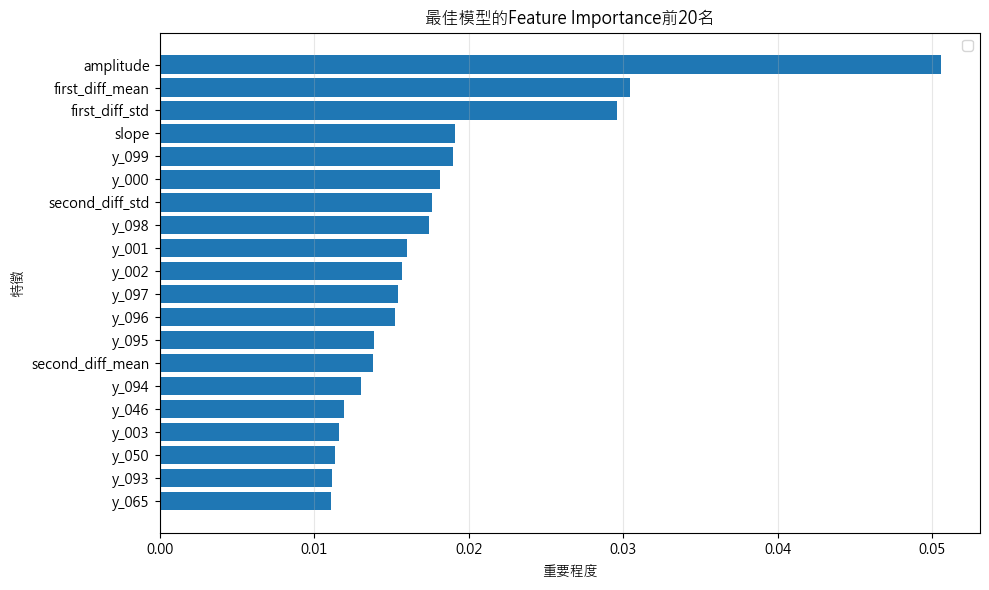

In [52]:
# 繪製圖表
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("重要程度")
plt.ylabel("特徵")
plt.title("最佳模型的Feature Importance前20名")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\feature_importance_top20.png')
plt.show()

## 模型調參

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib

In [54]:
# 調參前模型
baseline_model = joblib.load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v1\best_model.joblib')
baseline_model.fit(X_train_math, y_train.reset_index(drop=True))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
baseline_pred = baseline_model.predict(X_test_math)
baseline_accuracy = accuracy_score(y_test.reset_index(drop=True), baseline_pred)
print("模型調參前")
print(f"準確度: {baseline_accuracy:.3f}\n")

模型調參前
準確度: 0.816



In [56]:
# 設定 GridSearchCV
rf_model = RandomForestClassifier(random_state=10)
param_grid = {'n_estimators': [100, 150, 200],
              'max_depth': [None, 10, 20],
              'min_samples_split': [2, 3, 5],
              'min_samples_leaf': [1]}

In [57]:
# 開始 GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_math, y_train.reset_index(drop=True))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [58]:
print(f"最佳參數: {grid_search.best_params_}")
print(f"最佳CV準確度: {grid_search.best_score_:.4f}\n")

最佳參數: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
最佳CV準確度: 0.8034



In [59]:
# 使用最佳模型預測
best_model = grid_search.best_estimator_

In [60]:
train_pred = best_model.predict(X_train_math)
test_pred = best_model.predict(X_test_math)
train_accuracy = accuracy_score(y_train.reset_index(drop=True), train_pred)
test_accuracy = accuracy_score(y_test.reset_index(drop=True), test_pred)
print("模型調參後")
print(f"訓練數據準確度: {train_accuracy:.3f}")
print(f"測試數據準確度: {test_accuracy:.3f}")

模型調參後
訓練數據準確度: 1.000
測試數據準確度: 0.816


In [61]:
# 比較調參前後
print("----實驗結果----")
print(f"調參前準確度: {baseline_accuracy:.4f}")
print(f"調參後準確度: {test_accuracy:.4f}")
improvement = test_accuracy - baseline_accuracy
print(f"改善幅度: {improvement:+.4f}")
print("結論:", end=" ")
if improvement > 0:
    print("模型調參後，測試準確度提升。")
elif improvement < 0:
    print("模型調參後，測試準確度下降。")
else:
    print("測試準確度沒有改變。\n")

----實驗結果----
調參前準確度: 0.8163
調參後準確度: 0.8163
改善幅度: +0.0000
結論: 測試準確度沒有改變。



In [62]:
print(f"混淆矩陣:\n{confusion_matrix(y_test.reset_index(drop=True), test_pred)}")

混淆矩陣:
[[95  0  0  0  1  2  1  1]
 [ 0 85  0  2  1 11  0  1]
 [ 0  1 86  1  0  2 10  0]
 [ 0  1  8 73  4  1 12  1]
 [ 4  0  9  5 69  1 11  1]
 [ 1  4  2  9  9 73  2  0]
 [ 0  0  9  3  4  3 81  0]
 [ 5  0  1  0  1  1  1 91]]


In [63]:
print(f"分類報告:\n{classification_report(y_test.reset_index(drop=True), test_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.90      0.95      0.93       100
       cubic       0.93      0.85      0.89       100
 exponential       0.75      0.86      0.80       100
      linear       0.78      0.73      0.76       100
 logarithmic       0.78      0.69      0.73       100
   quadratic       0.78      0.73      0.75       100
  reciprocal       0.69      0.81      0.74       100
        sine       0.96      0.91      0.93       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



In [64]:
# 儲存最佳模型
joblib.dump(best_model, r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v1\best_model_tuned.joblib')

['D:\\Python\\我的AI作品集\\專案1_數學函數辨識\\models\\v1\\best_model_tuned.joblib']